# THEORY

## What is linear regression?
Linear regression is an analytical method which aids in the prediction of a dependent variable based on the value of another independent variable(s) (IBM, n.d.). It is commonly used for predictions, analysing trends as well as forecasting (GeeksforGeeks, 2026).

This form of analysis invloves the identification of the best straight line through the data points so that the indepdent variable(s) can be used to predict the dependent variable (IBM, n.d.). This is accomplished through the a method called *Least Squares*, which positions the line so as to reduce the gaps between the line and the actual data points. Predictions are considered more accurate the closer the line is to all the points (IBM, n.d.). An example of this method is a graph with people's heights (independent variable) and weights (dependent variable) plotted. The line of best fit will be drawn in, and thus an individuals weight can be predicted being knowing their height (IBM, n.d.).

## Definition
Essentially, linear regression is a type of supervised machine learning algorithm which predicts continous values by drawing a straight line through the data (GeeksforGeeks, 2026).

## Assumptions of Linear Regression (Roustaei, 2024):

Before using a linear regression model, four key assumptions needs to be checked:
(1)** Normality**
The errors (the gaps between the predicted and actual values) should follow a normal distibution, this is shown in the form of a bell shapped curve. Normality can be checked visually using a histrogram or statistically using the Shapiro-Wilk test (P>0.05 normality assumption is met).

(2) **Equal Variance **
The erros should be consistently spread out accross all values, thus there should be no pattern observed upon being plotted. A random, even scatter means this assumption is satisfied.

(3)** Linearity **
There should always be a linear relationship between the dependent and indepedent variables. When the errors are plotted against the independent variables, there should be no clear pattern, rather the line which goes through the points should be roughlt flat.

(4) **No Collinearity **
The independent variables should not be too closely related to each other. This correlations (or lack thereof) is measured using the Variance Inflation Factro (VIF), whereby a VIF of 1 indicates a lack of correlation, between 1-5 is a mild correlation, between 5-10 a strong correlation while a VIF of above 10 is now a serious problem to the point that predictions would now become reliable.

## Types of Linear Regression (Statistics Solution, 2025)

All of the linear regression models have one dependent variable but the different comes with the independent variables:
**Simple Linear Regression**
A single dependent and an indepdent variable, which can be binary (EG: YES or NO).

**Multiple Linear Regression**
Two or more indepdent variables, all measured on a numerical scale.

**Logistic Regression**
In this case the dependent variable is binary and while there can be  two or more independent variables which can be binary or numerical.

**Ordinal Regression**
The dependent variable here has ranked categories (EG: best, better, best) and independent variables (one or more) are  binary or categorical.

**Multinominal Regression**
The independent variable has multiple unordered categories and independent variable (one or more)can be numerical or binary.

**It should be noted that in this assignment I will be focusing on multiple linear regression. **

# APPROPRIATE DATA SET

## Source of the dataset that I will be using:
*   Source -> Kaggle
*   Dataset title -> Medical Cost Personal Datasets
*   Author -> Miri Choi
*   Link -> https://www.kaggle.com/datasets/mirichoi0218/insurance
*   In-text reference -> (Choi, 2018)

## Why is this dataset appropriate for linear regression?
This dataset is appropriate for linear regression analysis because it essentially aligns with the thoery information above stated about this type of model. Linear regression predicts a continuous dependent variable from one or more independent variables (IBM, n.d.; GeeksforGeeks, 2026), and in this dataset, charges is continuous, whilst the other predictors (age, bmi, children, smoker, sex, and region) support the use of multiple linear regression (Statistics Solution, 2025).

The dataset in theory should reflect linear relationships, such as the positive association between bmi and medical costs, which is supported by evidence that higher body weight is linked to increased healthcare expenditure (Ward *et al*., 2021). Additionally, categorical variables can be encoded numerically, allowing all predictors to be incorporated into the model and enabling the fitting of a least squares regression line (IBM, n.d.).

Moreover, the dataset allows for testing of the linear regression assumptions of normality, equal variance, linearity, and no collinearity, thus ensuring that the model in theory should be reliable (Roustaei, 2024). Overall, its structure, variable types, and real world relevance make it appropriate for predicting and interpreting insurance costs using multiple linear regression.



# ANALYSIS THAT NEEDS WILL BE CONDUCTED

The aim of this analysis is to use multiple linear regression to predict insurance charges given the various predictors.
How will I go about this:

**1) Perform Exploratory Data Analysis (EDA)**
*   Load the dataset and inspect its shape, data types, and first few rows so I can get a general idea of what's going on within the dataset
*   I'll check for missing values and duplicates (these variables can be dropped or I will just handle them in a way I deem fit:)
*   Since there are categorical variables, they need to be encoded (sex, smoker, region) using Label Encoding since the model requires numerical inputs
*   Following this, I'll generate the summary statistics to understand distributions
*   In terms of the visuals, I will use a correlation matrix and plots (histograms, scatter plots, boxplots) to understand the relationships between the independent variables and the dependent variable (charges)

**2) Perform Feature Selection**
*  From the correlation matrix I'll be able to identify which features have a strong relationship with charges

**3) Train the linear regression model**
*   Before training the model, the data needs to be split into training and test sets (80/20)
*   The training dataset will be trained using the multiple linear regression model

**4) Interpret and evaluation of the model**
*   As models can be prone to overfitting, I will compare the train score against the test score to check for this.
 *   I will look at the R² score, MAE, MSE and RMSE

**5) Hyperparameter Tuning**
*   Apply RandomizedSearchCV to try and improve the model

















# PYTHON CODE

## Import Python Libraries

In [ ]:
import pandas as pd #ANALYTICAL LIBRARY / DATA ANALYSIS
import sklearn as sk #ALGORITHMS & ML TOOLS
import numpy as np #MATHEMATICAL FUNCTIONS - ARRAYS
import seaborn as sns #PLOTTING
import matplotlib.pyplot as plt #PLOTTING

from sklearn.linear_model import LinearRegression #Linear Regression

from sklearn.model_selection import train_test_split #SPLIT DATA INTO TRAIN AND TEST

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #HELPS SO WE CAN EVALUATE HOW ACCURATE THE LINEAR REGRESSION MODEL IS

from sklearn.preprocessing import OneHotEncoder  #Dummy Variables/ Categories -> numbers
from sklearn.preprocessing import LabelEncoder #COMPUTERS CANT SPEAK WORDS, THEY SPEAK NUMBERS

from sklearn.preprocessing import MinMaxScaler   #Scale data
from sklearn.preprocessing import StandardScaler #encode our data to make it numerical 0/1 (cause it's in word format)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report #HELPS TO MEASURE HOW GOOD THE MODEL IS AT MAKING PREDICTIONS

from sklearn.model_selection import cross_val_score #CROSS VALIDATION

from statsmodels.stats.outliers_influence import variance_inflation_factor

## Retrieving the data from Kaggle

Before the dataset can be loaded, I need to get it from the Kaggle website using this link: https://www.kaggle.com/datasets/mirichoi0218/insurance

The dataset was copied from the Kaggle CLI using the copy (Ctrl + C) and paste (Ctrl + V) commands:

*Control C (Kaggle CLI) Control v*

In [ ]:
#!/bin/bash
!kaggle datasets download mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 27.5MB/s]



As we can see the data is zipped - *Downloading insurance.zip*

=> Therefore I need to unzip the dataset from Kaggle so I can continue I can begin with the analysis
I will use:

*!unzip *

In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


## Load the dataset

The insurance dataset was loaded into a pandas DataFrame using the read_csv() function

In [ ]:
df = pd.read_csv('insurance.csv')

To get an idea of what where working with and how the data looks, I will display the first 10 rows of this dataset.
This is performed using the head() function

In [ ]:
df.head(10) #I put 10 between the brackets because I wanted to view the first 10 rows of the dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## Cleaning the data

Data cleaning is an important step in the data analysis process because raw datasets usually contain missing values, duplicates, and errors that can reduce the accuracy of results (GeeksforGeeks, 2026). If I do i not identify and correct these issues, they can lead to biased and unreliable model outcomes, thus weakening the conclusions that I would draw from  the data (Sharifnia *et al*., 2026). Therefore, data cleaning ensures that the dataset is accurate, consistent, and suitable for analysis by identifying and correcting anomalies such as missing values and outliers (Sharifnia *et al*., 2026).

In practice, data cleaning involves removing irrelevant or duplicate entries, fixing structural inconsistencies, managing outliers, and handling missing data through techniques such as deletion or imputation (GeeksforGeeks, 2026). This process improves data quality and thus would provide a more reliable analysis and interpretation, especially during EDA where accurate insights are needed for to make the best decisions (GeeksforGeeks, 2026).

Let's identify the type of data variables we are working with. This is important because machine learning models cannot work with categorical data, only numerical. Thus as 'smoker', 'region' and 'sex' are cetegorical, they need to be converted to a numerical so that analysis can take place.

## Encoding the data

In [ ]:
df.info() # I can see that 'sex', 'smoker' and 'region' are classified as 'object' data types -> WE CANT WORK WITH THESE IN THIS FORMAT
          # Converesly, 'age', 'bmi', 'children' and charges are classified as 'int64' and 'float64' -> WE CAN WORK WITH THESE IN THIS FORMAT

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Let's fix these: 'sex', 'smoker' and 'region' so that they are acceptible data types for analysis:

I used the LabelEncoder function from scikit learn. It is used to change the the categorical variables into numerical ones, giving each category a unique value while keeping their order (GeeksforGeeks, 2026).

In [ ]:
df.select_dtypes(include=['object', 'category']) # Lets find only the categorical values

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


Let's convert the categorical variables => numerical so analysis can continue

We will use LabelEncoder

In [ ]:
#ENCODING

encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


RESULTS AFTER ENCODING:

0 -> female

1 -> male

RESULTS AFTER ENCODING:

3 -> southwest

2 -> souteast

1 -> northwest

RESULT AFTER ENCODING:

1 -> yes

0 -> no

Now that all the variables are numerical, we can now proceed

Let's check for duplicate values

In [ ]:
df.duplicated() #checking for duplicates
# (GeeksforGeeks, 2026)

,0
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


Since the function df.duplicated() says that the dtype:bool, this showed that it checked for duplicate rows (GeeksforGeeks, 2026).
The output is 'False' for each row, so this means that the rows are each unique => there are NO duplicates

Now let's look for null/missing values using the following function: df.isnull().sum()

In [ ]:
df.isnull().sum() #checking for null/missing values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.isna().sum() #checking for null/misisng values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Mean imputation

The isnull() and isna() are both from Pandas, and both perform the same function = checking for null/missing values. Doing both and both returning the same result reinforces the absence of null values (GeeksforGeeks, 2025).

Ultimately, the output for each of the predictor variables when we looked for null values was 0
=> there are no missing values

Data imputation is the process of handling missing values in a dataset by replacing them with estimated or calculated values (GeeksforGeeks, 2025). Missing data can occur due to errors, missing information, or inconsistencies during data collection or entry. It is important to address these gaps because they can affect the accuracy of models and lead to biased results if left untreated.

-> I used mean imputation for each variable: this method of imputation replaces the missing values with the overall average (mean) of the dataset

In [ ]:
df['age'].fillna((df['age'].mean()), inplace=True)

/tmp/ipykernel_1563/1123070014.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna((df['age'].mean()), inplace=True)


In [ ]:
df['sex'].fillna((df['sex'].mean()), inplace=True)

/tmp/ipykernel_1563/2313689339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sex'].fillna((df['sex'].mean()), inplace=True)


In [ ]:
df['bmi'].fillna((df['bmi'].mean()), inplace=True)

/tmp/ipykernel_1563/3227488821.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna((df['bmi'].mean()), inplace=True)


In [ ]:
df['children'].fillna((df['children'].mean()), inplace=True)

/tmp/ipykernel_1563/3609989587.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna((df['children'].mean()), inplace=True)


In [ ]:
df['smoker'].fillna((df['smoker'].mean()), inplace=True)

/tmp/ipykernel_1563/2845985457.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['smoker'].fillna((df['smoker'].mean()), inplace=True)


In [ ]:
df['region'].fillna((df['region'].mean()), inplace=True)

/tmp/ipykernel_1563/3563987877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['region'].fillna((df['region'].mean()), inplace=True)


In [ ]:
df['charges'].fillna((df['charges'].mean()), inplace=True)

/tmp/ipykernel_1563/734293351.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['charges'].fillna((df['charges'].mean()), inplace=True)


Let's see what our data looks like now after some cleaning

In [ ]:
df.head(20)

# Everything is numerical, good!

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
5,31,0,25.740,0,0,2,3756.62160
6,46,0,33.440,1,0,2,8240.58960
7,37,0,27.740,3,0,1,7281.50560
8,37,1,29.830,2,0,0,6406.41070
9,60,0,25.840,0,0,1,28923.13692


In [ ]:
df.info() # Just double checking that there are no strings:)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


## EDA

EDA is the process of exploring and visualising the dataset so as to understand the characteristics, patterns, and relationships between variables better (GeeksforGeeks, 2026). This will provide a good and clear overview of the data. During this analysis, I will also outliers that could affect analysis.

Let's first look at the data and see what's going on currently.
This will allow me to see if I can identify any unusual values of patterns with my naked eyes.

In [ ]:
df.describe() # Gives me an overview of the numerical data

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


The above table shows us that the dataset has 1338 observations, and that there are no missing values. This is good cause know we can use this data for further analysis. The age and BMI variables, showed that there was approximately symmetric distributions. This is shown through the mean and median values which are closely aligned.

Converesly, charges showed a strong positive skew, with its mean being much higher than the median. Additionally, there are a wide range of values, which shows the presence of extreme high costing outliers.

Additionally, the smoking variable was imbalanced because it has a lower proportion of smokers than non-smokers.

## Pairplots/ Scatter Plots

A pair plot is a set of graphs that shows the relationships between different variables against each other from the dataset. It includes a combination of scatter plots and histrograms that gives an overview of data distributions and relationships. It is a good tool to use when doing EDA because it helps identify patterns, relationships, and outliers in the data.
However, it should be noted that it is kind of tricky to read:(

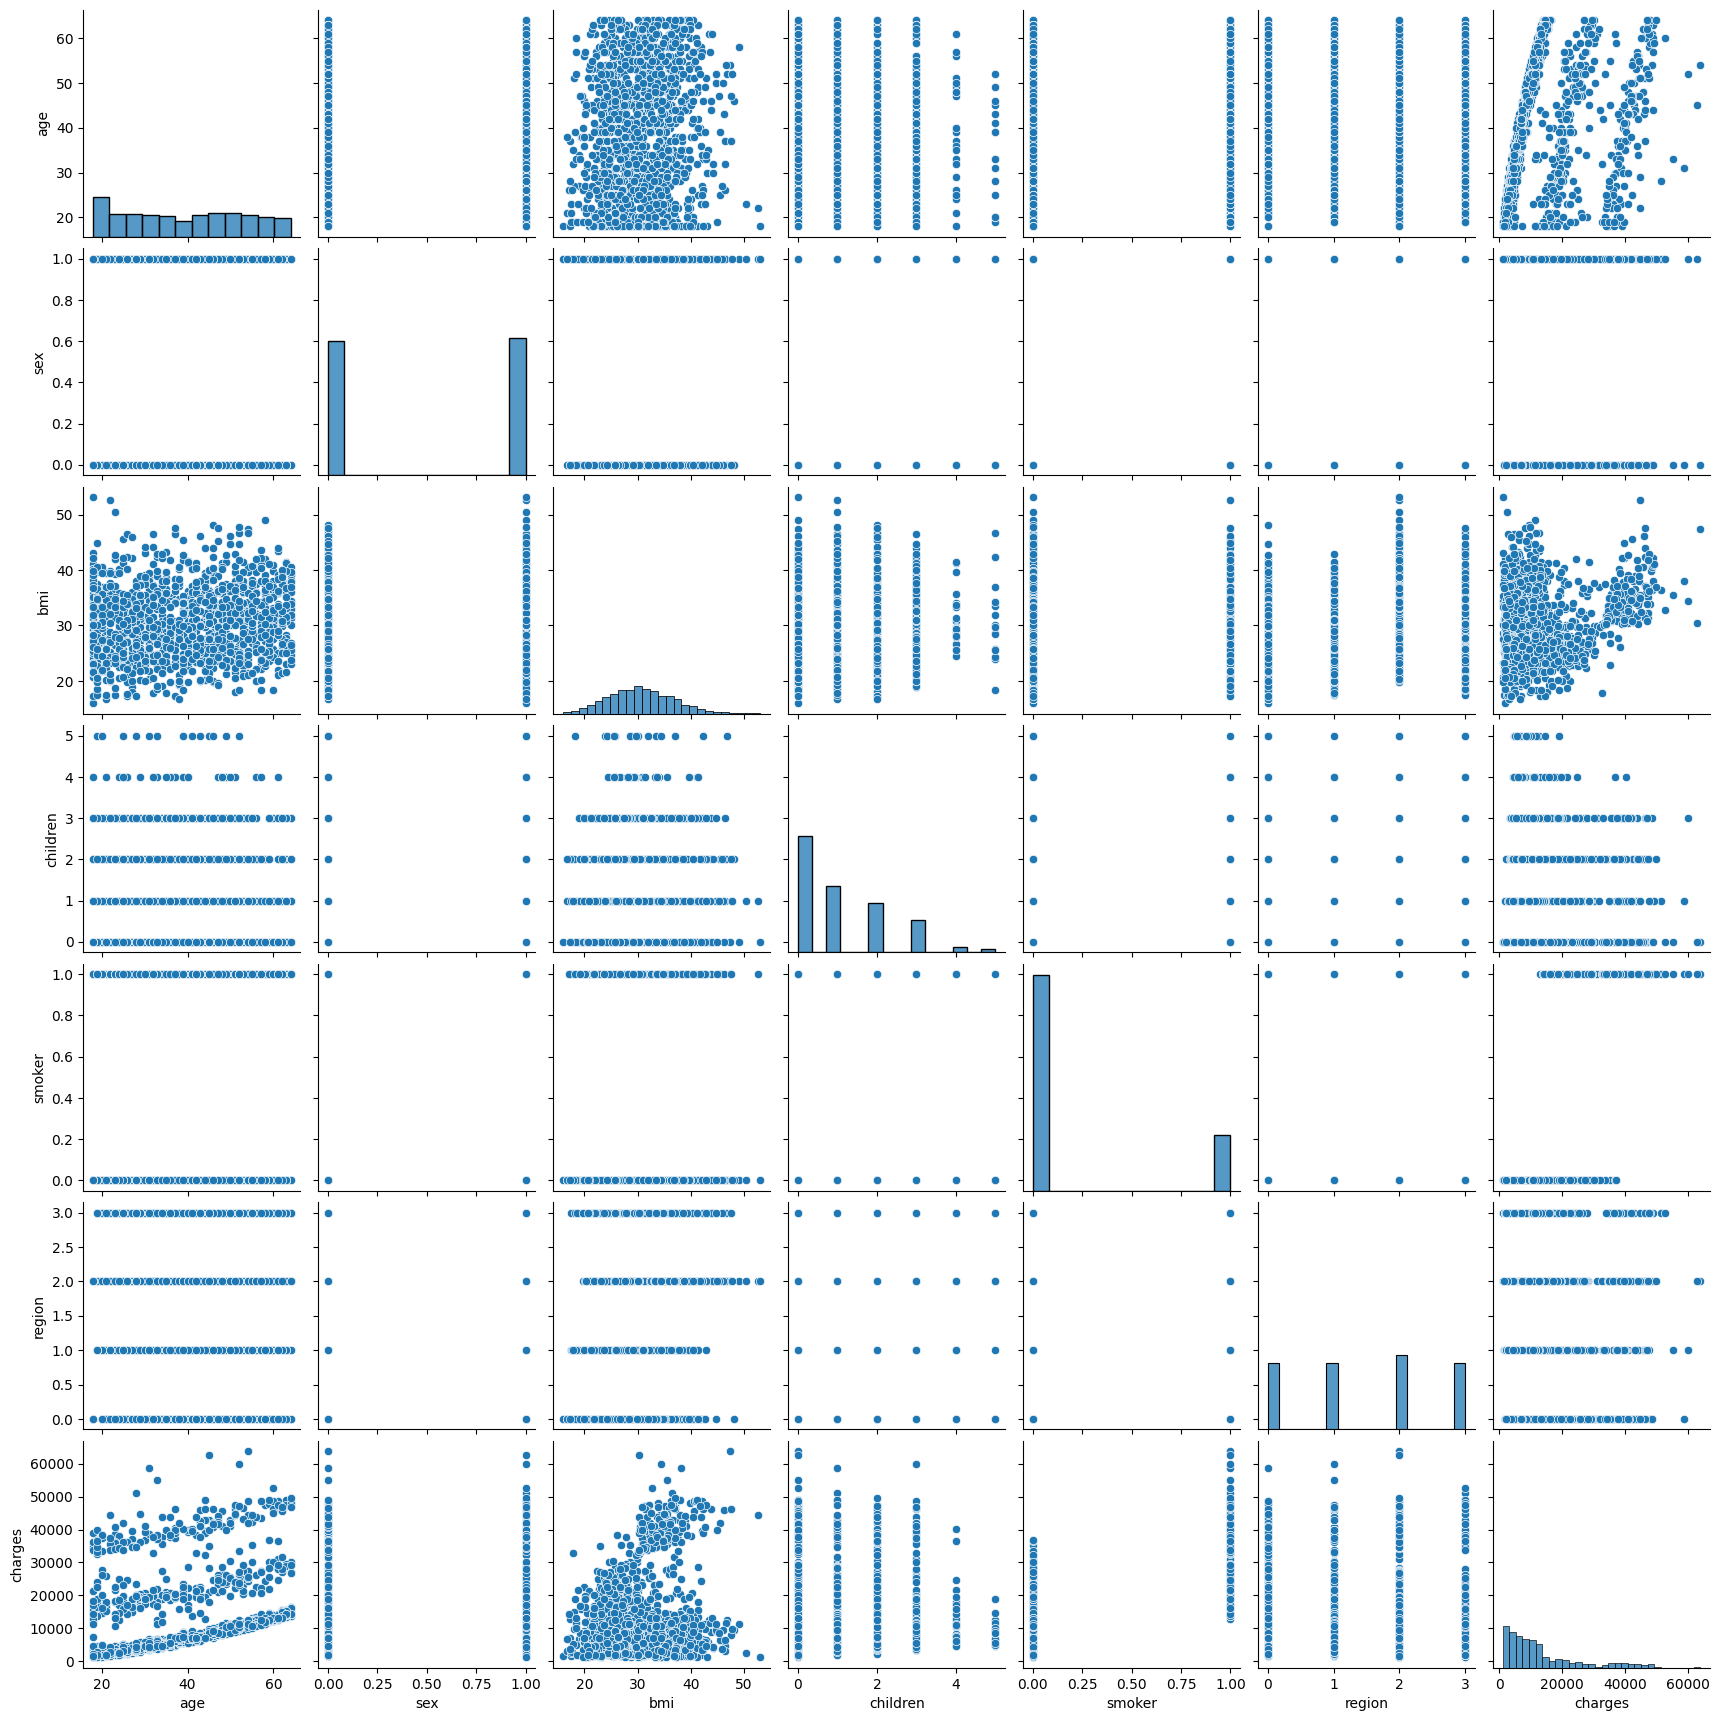

In [ ]:
sns.pairplot(df) # let's look at all the features/variables

INSIGHTS FROM THE PAIRPLOT:

(1) Smoker vs charges shows a clear separation

=> smokers tend to have much higher medical costs

(2) There is a slight upward trend when it comes to age vs charges:

=> older people seem to generally have higher charges


(3) There seems to be a weak to moderate positive relationship between bmi and charges:

=> people with higher bmi are offten associated with higher costs

(4) There doesn't really seem to be a strong relationship in terms of sex and region with charges, respectively.


Now let's look at the relationships individually to get a better view and understanding

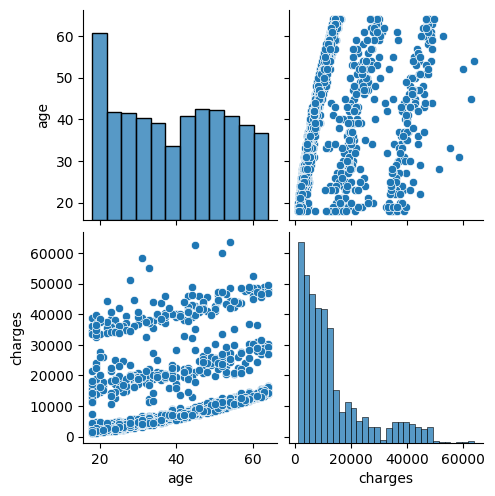

In [ ]:
sns.pairplot(df, vars=['age', 'charges'])

# 0 -> female
# 1 -> male

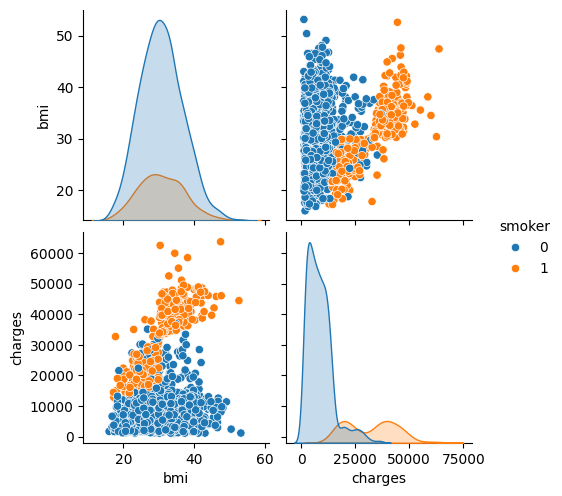

In [ ]:
sns.pairplot(df, vars=['bmi', 'charges'], hue='smoker')

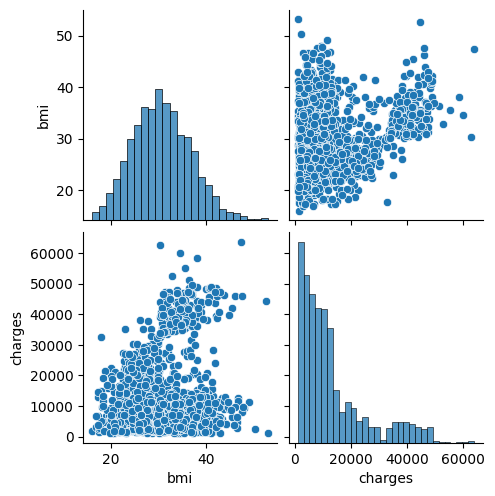

In [ ]:
sns.pairplot(df, vars=['bmi', 'charges'])

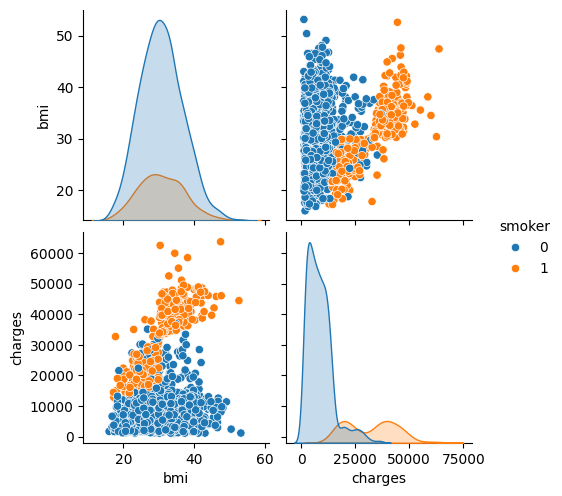

In [ ]:
sns.pairplot(df, vars=['bmi', 'charges'], hue='smoker')

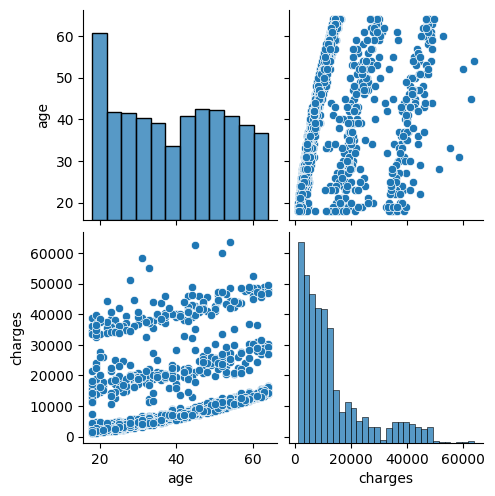

In [ ]:
sns.pairplot(df, vars=['age', 'charges'])

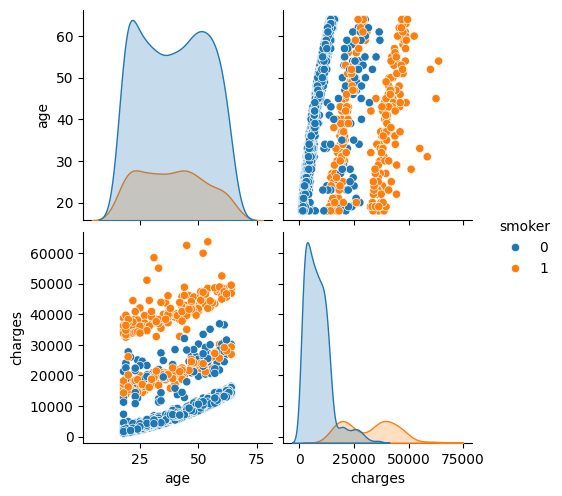

In [ ]:
sns.pairplot(df, vars=['age', 'charges'], hue='smoker')

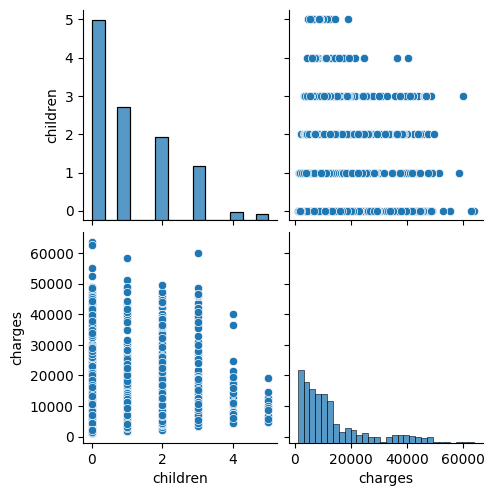

In [ ]:
sns.pairplot(df, vars=['children', 'charges'])

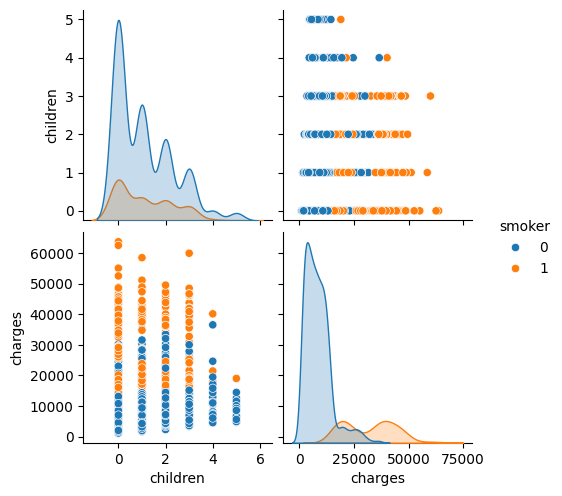

In [ ]:
sns.pairplot(df, vars=['children', 'charges'], hue='smoker')

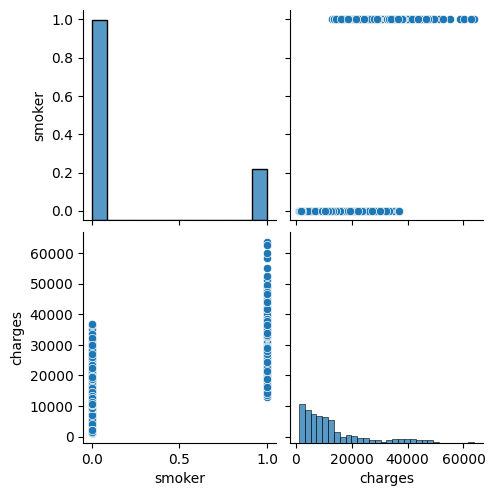

In [ ]:
sns.pairplot(df, vars=['smoker', 'charges'])

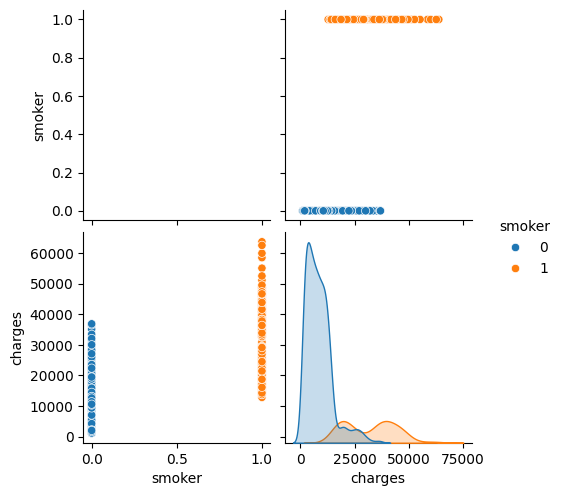

In [ ]:
sns.pairplot(df, vars=['smoker', 'charges'], hue='smoker')

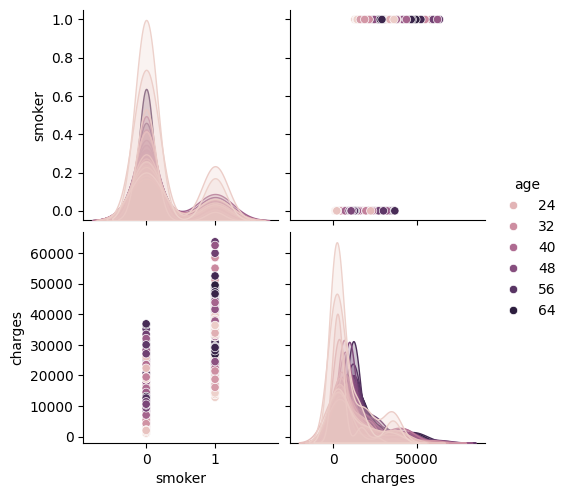

In [ ]:
sns.pairplot(df, vars=['smoker', 'charges'], hue='age')

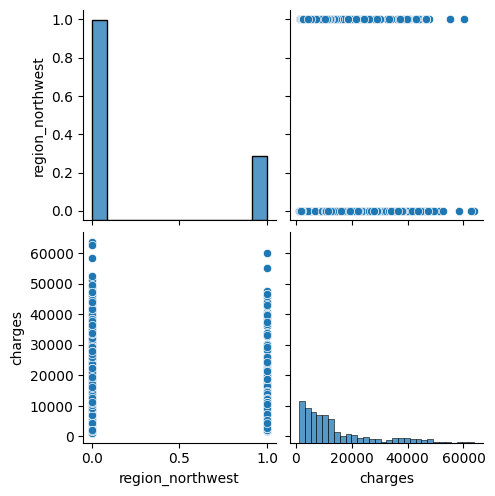

In [ ]:
sns.pairplot(df, vars=['region_northwest', 'charges'])

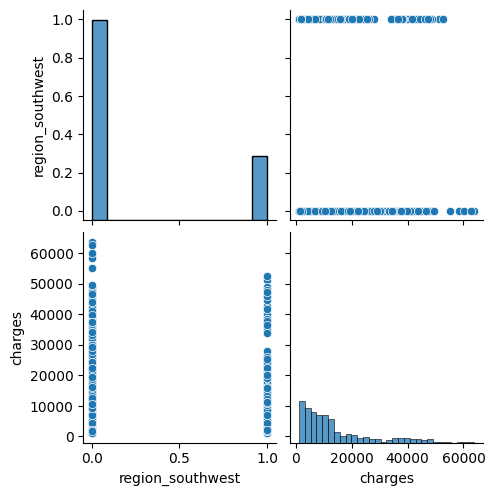

In [ ]:
sns.pairplot(df, vars=['region_southwest', 'charges'])

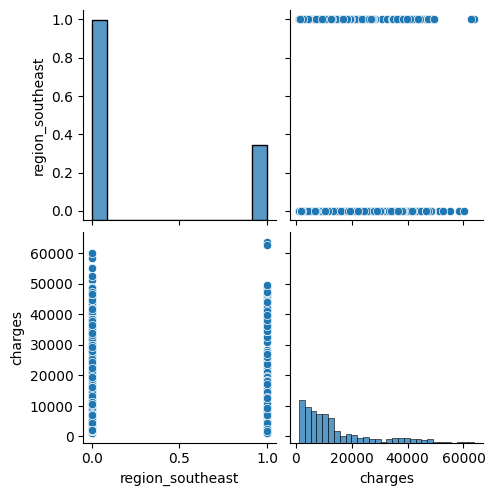

In [ ]:
sns.pairplot(df, vars=['region_southeast', 'charges'])

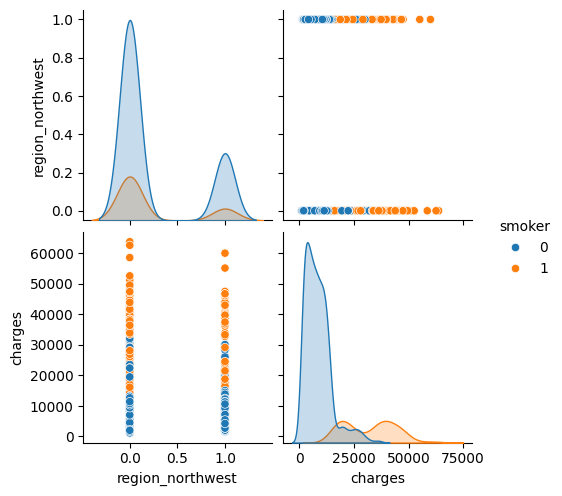

In [ ]:
sns.pairplot(df, vars=['region_northwest', 'charges'], hue='smoker')

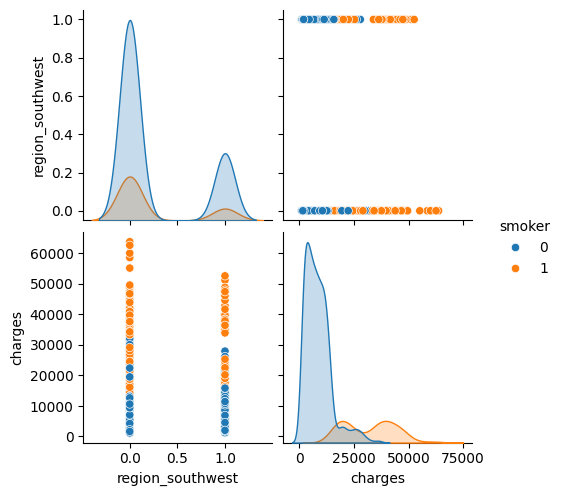

In [ ]:
sns.pairplot(df, vars=['region_southwest', 'charges'], hue='smoker')

## Outliers

It's important to identify and remove outliers because they affect the line of best fit and the Pearson correlation coefficient, which may lead to misleading or different conclusions about the data (Laerd Statistics, 2020).

So this is why I am dealing with the outliers before looking at the correlation matrices.

### Identify outliers visually



<Axes: xlabel='age'>

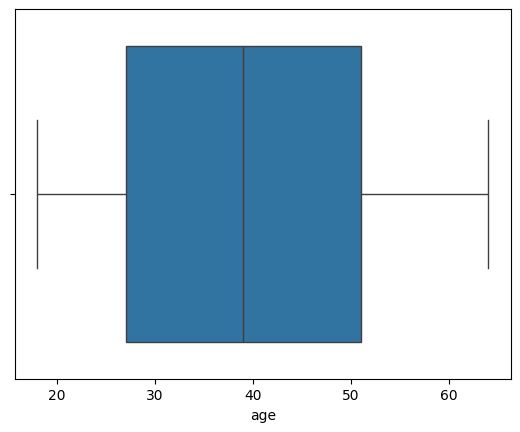

In [ ]:
sns.boxplot(x=df['age'])

The dataset mainly includes adults between about 28 and 51 years old, with a fairly even distribution. There seems to be no outliers (GeeksforGeeks, 2025).  

To try and properly see if sex has an affect on chargers let's use a different code provided by Nadia. It is similar to the Titantic data EDA code:
*sns.boxplot(data=df, x='Survived', y='Fare')*

<Axes: xlabel='sex', ylabel='charges'>

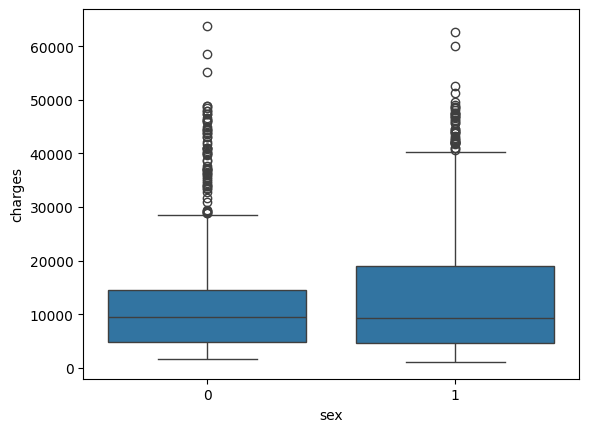

In [ ]:
sns.boxplot(data=df, x='sex', y='charges')

# This code uses seaborn to create a boxplot to help us compare charges between sexes => it gives more useful information than the previous plots

This boxplot above and below shows that charges are kind of similar for sex_0 and sex_1. This is is shown through the medians of both groups being around the same range, plus there is quiet an overlap in their interquartile (IQR) ranges.

In the above boxplot sex_0 appears to have a slightly wider spread at the upper end, while both groups have high outliers reaching above 60 000.

=> These boxplots suggests that sex by itself is probably isn't a dominant predictor of charges compared with other variables that usually create stronger separation.

<Axes: xlabel='bmi'>

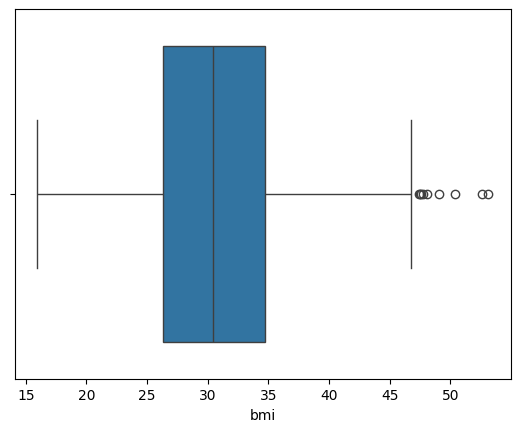

In [ ]:
sns.boxplot(x=df['bmi'])

The data is slightly skewed to the right, with outliers being found from a bmi of around 47 to about 58.

(Patil, 2023)

<Axes: xlabel='children'>

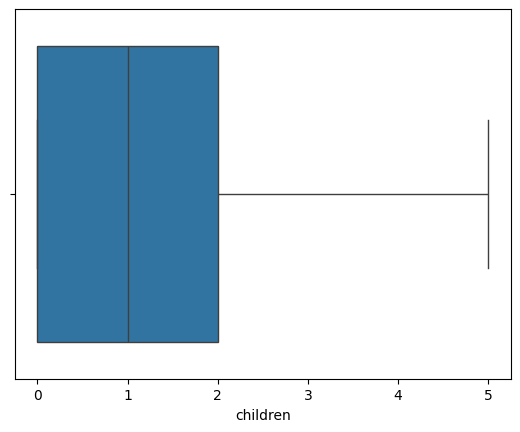

In [ ]:
sns.boxplot(x=df['children'])

<Axes: xlabel='charges'>

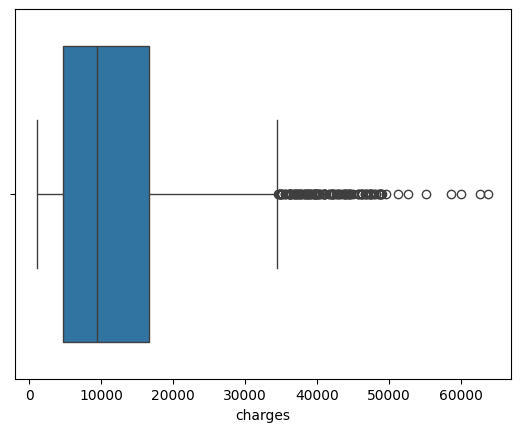

In [ ]:
sns.boxplot(x=df['charges'])

The data is highly skewed to the right.

(Patil, 2023)

I've decided to use the seaborn barplot instread of the boxplot because it makes it easier to understand (GeeksforGeeks, 2025).

This is useful for binary classification because it makes it easy to compare the two groups (like smoker vs non-smoker) and quickly see which one has higher or lower values.

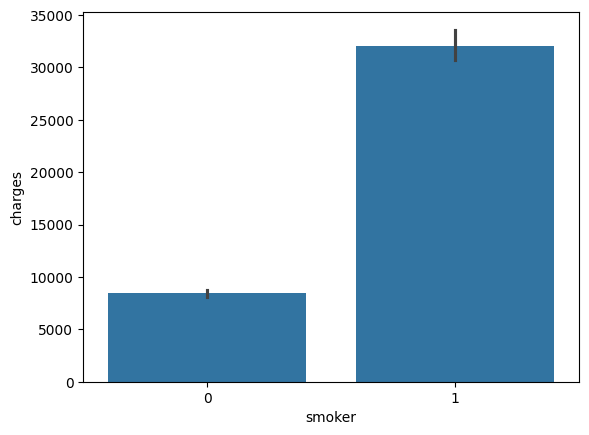

In [ ]:
ax = sns.barplot(data=df, x='smoker', y='charges')

There is a disproportionally high amount of smokers compared to non-smokers.

I have used the seaborn barplot again instead of the boxplot because it makes it easier to understand the regions and how they influence charges (GeeksforGeeks, 2025).

The plot is useful because the height of each bar shows which regions have higher or lower charges, so I can visualually compare and try and identify patterns.

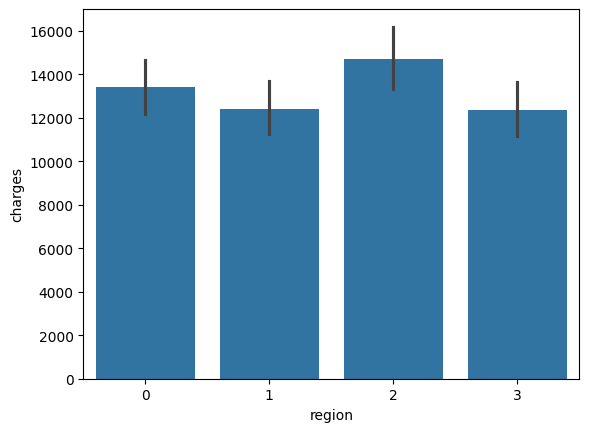

In [ ]:
ax = sns.barplot(data=df, x='region', y='charges')


Individuals in region 2 have the highest insurance charges, while those in region 1 have the lowest

The seaborn boxplot (GeeksforGeeks, 2025), also works well for sex.

This is because the bar heights make it easy to see if one group has higher or lower medical costs than the other. It is slightly easier to understand that its boxplot.  

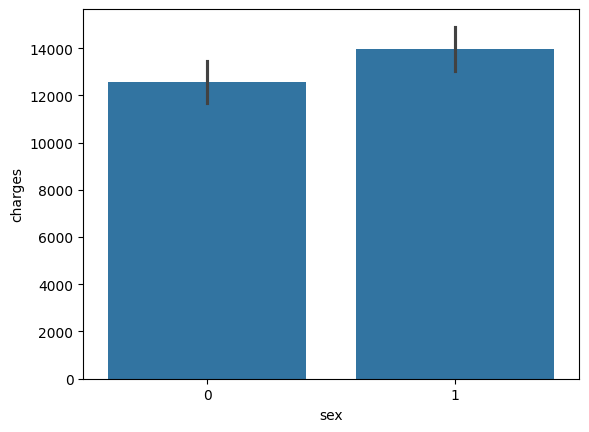

In [ ]:
ax = sns.barplot(data=df, x='sex', y='charges')

Males (1) have higher insurance charges.

### Identify outliers using the IQR

It has been established that there are outliers for sex, bmi and smoker. That was step 1 in the outlier process = identification.

Now what are we going to do with these outliers?

(1) Find the IQR of the variables with outliers (but because I am paranoid I will also do this for the variables which appear not to have outliers:)

(2) Remove the outliers, thus cleaning the data.

NOW LET'S GIVE THESE STEPS SOME CONTEXT:

To try and measure the datas distribution, we us the IQR. It particularly is used to measures how spread out the middle 50% of the data is. It is calculated as (Patil, 2023):

IQR = Q3 − Q1 (Patil, 2023)

To find outliers, two limits are set:

Lower bound: Q1 − 1.5 × IQR (Patil, 2023) Upper bound: Q3 + 1.5 × IQR (Patil, 2023)

Values that are identified bove the upper bound or below the lower bound are outliers (Patil, 2023). This means thats these values are much smaller or larger than most of the data, their essentially anomolies.

In [ ]:
# Finding the number bmi outliers

q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5*IQR
upper = q3 + 1.5*IQR

outliers = df[(df['bmi'] < lower) | (df["bmi"] > upper)]

print(len(outliers))

9


In [ ]:
# Finding the number smoker outliers

# q1 = df['smoker'].quantile(0.25)
# q3 = df['smoker'].quantile(0.75)
# IQR = q3 - q1

# lower = q1 - 1.5*IQR
# upper = q3 + 1.5*IQR

# outliers = df[(df['smoker'] < lower) | (df["smoker"] > upper)]

# print(len(outliers))

WHY AM I NOT FINDING THE IQR AND REMOVING THE OUTLIERS OF SMOKER?

This is because smoker is binary variable (it has two categories 0 and 1). It does not have continous numerical values like bmi and charges.  Thus if I were to find the IQR and subsequentyl remove the outliers this could remove a whole groups (trust me when I say this, this happened to me during this assignment ans it took me a hot minute to figure out why I no longer hasd any smokers). This would then distort the dataset and reducing its interpretability.

Furthermore, not all extreme or distinct values should be removed, because they represent meaningful real world variation (Hleap, n.d.). For example, in biological studies, outliers may indicate important genes of interest, while in business contexts, they may reflect emerging trends(Hleap, n.d.). Similarly, the difference  between smokers and non-smokers is meaningful and so I need to keep these variables intack to preserve the integrity of the analysis.

In [ ]:
# Finding the number charges outliers

q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5*IQR
upper = q3 + 1.5*IQR

outliers = df[(df['charges'] < lower) | (df["charges"] > upper)]

print(len(outliers))

139


In [ ]:
for col in df.select_dtypes(include='number').columns:

  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  IQR = q3 - q1
  lower = q1 - 1.5*IQR
  upper = q3 + 1.5*IQR

  outliers = df[(df[col] < lower) | (df[col] > upper)]
  if len(outliers):
    print(col, len(outliers))
  else:
    continue

bmi 9
smoker 274
charges 139


In [ ]:
df.shape # Tells us how many columns and rows we have before outliers are removed

(1338, 7)

So it has been statistically confirmed that there are no outliers for age, sex children and region.

However there are outliers for the following:

bmi 9

smoker 274

charges 139


We also have 1338 -> rows and 7 -> columns

Let's look at the correlations between the predictors and charges before we remove the outliers

I used grid heatmaps to visualise the correlations between the predictor variables and charges. I used this visualisation because it makes it easy to
compare many variables at once by showing their relationships in a simple grid format (GeeksforGeeks, 2024).

The colours also make it easy to see if variables are strongly related or not.

I generated 3 of the same grid heatmaps but in different colours.


The grid heatmaps use a gradient scale, whereby the darker the grid block the less correlated the variable is the charges.

Conversely, the light the gird block the greater the correlation the variable has to charges.

<Axes: >

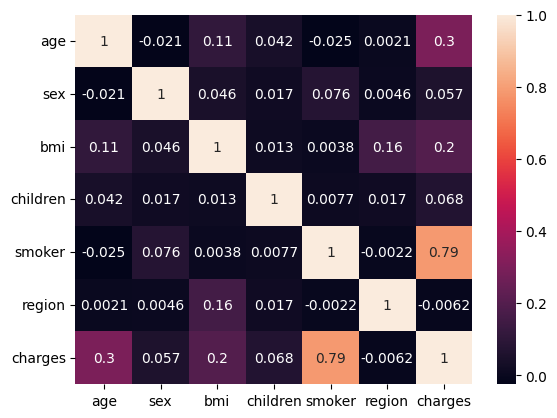

In [ ]:
correlation = df.corr()

sns.heatmap(correlation, annot=True)

Highest correlation to charges => smoker (0.79)

Lowest correlation to charges => region (-0.0062)

<Axes: >

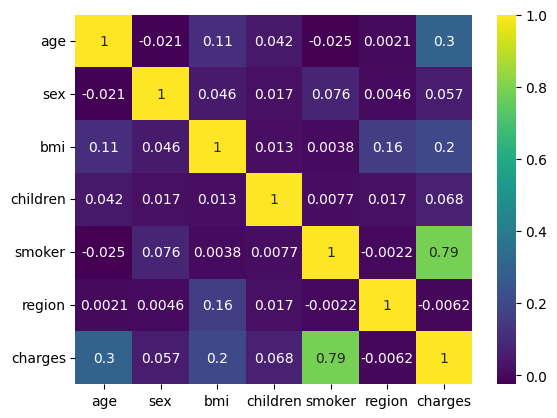

In [ ]:
plt.subplots()
sns.heatmap(correlation, annot=True, cmap="viridis")

<Axes: >

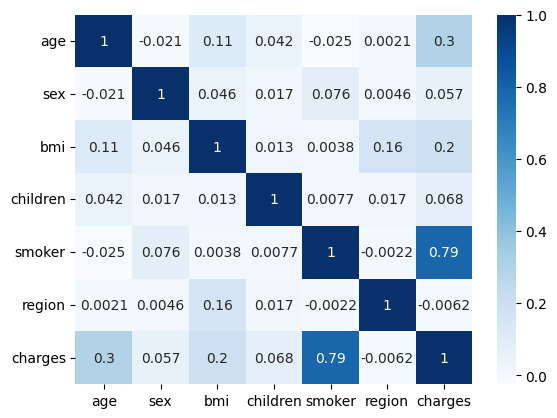

In [ ]:
plt.subplots()
sns.heatmap(correlation,annot=True, cmap='Blues')

In [ ]:
df.corr(method='pearson', min_periods=1, numeric_only=False) # provides us with the pairwise correlation of thecolumns, excluding null values.

# source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html


This statistical analysis method with pearson's correlation confirms the visual findings in the grid heatmaps generated above:

Highest correlation to charges => smoker (0.79)

Lowest correlation to charges => region (-0.0062)

Now we have identified the number of outliers, now lets remove them

In [ ]:
Columns = 'bmi'

q1 = df[Columns].quantile(0.25) #25%
q3 = df[Columns].quantile(0.75) #75%

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

print(q1, q3)
print(IQR)
print(lower, upper)


outliers = df[(df[Columns] < lower) | (df[Columns] > upper)]
print(Columns, len(outliers))

#CLEAN THE DATA BY REMOVING THE OUTLIERS
df = df[(df[Columns] >= lower) & (df[Columns] <= upper)]

26.29625 34.69375
8.3975
13.7 47.290000000000006
bmi 9


In [ ]:
# Columns = 'smoker'

# q1 = df[Columns].quantile(0.25) #25%
# q3 = df[Columns].quantile(0.75) #75%

# IQR = q3 - q1

# lower = q1 - 1.5 * IQR
# upper = q3 + 1.5 * IQR

# print(q1, q3)
# print(IQR)
# print(lower, upper)


# outliers = df[(df[Columns] < lower) | (df[Columns] > upper)]
# print(Columns, len(outliers))

#CLEAN THE DATA BY REMOVING THE OUTLIERS
# df = df[(df[Columns] >= lower) & (df[Columns] <= upper)]

In [ ]:
Columns = 'charges'

q1 = df[Columns].quantile(0.25) #25%
q3 = df[Columns].quantile(0.75) #75%

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

print(q1, q3)
print(IQR)
print(lower, upper)


outliers = df[(df[Columns] < lower) | (df[Columns] > upper)]
print(Columns, len(outliers))

#CLEAN THE DATA BY REMOVING THE OUTLIERS
df = df[(df[Columns] >= lower) & (df[Columns] <= upper)]

4738.2682 16586.49771
11848.22951
-13034.076065 34358.841975
charges 138


Let's see what the dataset is look like following the removal of outliers

In [ ]:
df.shape

(1191, 7)

After removing the outliers we now have  1191 -> rows and 7 -> columns

Now let's check again to see whether we were successful at removing the outliers

In [ ]:
# how to check for outliers using a "for loop"

# code is from Nadia, from the Decision Trees notebook (April 16th)
# (Nadia, 2026)

for col in ['bmi', 'charges', 'age']:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_boundry = Q1 - 1.5*IQR
  upper_boundry = Q3 + 1.5*IQR

  outliers = df[(df[col] < lower_boundry) | (df[col] > upper_boundry)]
  if len(outliers):
    print(col, len(outliers))
  else:
    print(col,"NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)")

bmi 7
charges 53
age NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)


We still have some outliers for charges and bmi

In [ ]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000,1191.000000
mean,39.010915,0.487825,29.993648,1.087322,0.114190,1.492024,9901.104142
std,14.056634,0.500062,5.870584,1.216455,0.318175,1.110558,7187.379901
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,26.000000,0.000000,25.800000,0.000000,0.000000,1.000000,4408.695900
50%,39.000000,0.000000,29.700000,1.000000,0.000000,1.000000,8347.164300
75%,51.000000,1.000000,33.770000,2.000000,0.000000,2.000000,12953.594600
max,64.000000,1.000000,46.750000,5.000000,1.000000,3.000000,34303.167200


Following the identification of the outliers and the removal of the ones i deemed appropriate, the dataset is now considerably cleaner.

It now contains 1191 rows. It still does not have missing values.

Variables such as age and bmi stayed fairly normally distributed, whilst sex is balanced between categories. The smoker variable is still imbalanced, with fewer smokers than non-smokers. And charges is slightly skewed to the right.

However, the extreme values have been reduced, and so this shows that yes some outliers but others still remain and so this ensures that there is realistic variation in the data.

<Axes: xlabel='bmi'>

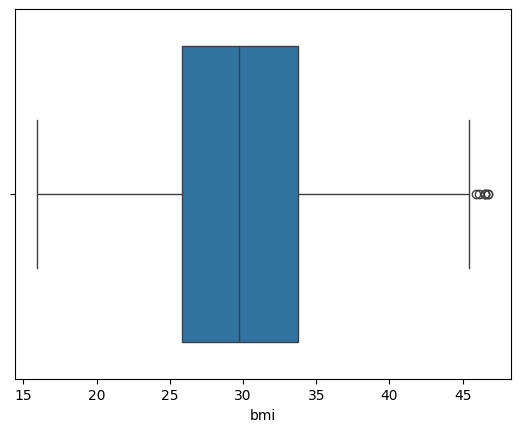

In [ ]:
sns.boxplot(x=df['bmi'])

The number of outliers for bmi has been reduced and so the data is a little more better distributed

<Axes: xlabel='smoker'>

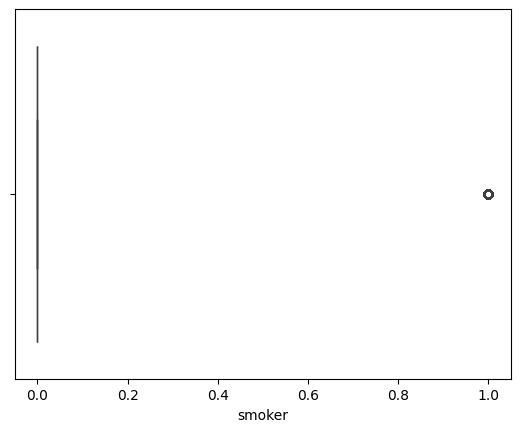

In [ ]:
sns.boxplot(x=df['smoker'])

There are no outliers for smokers, however, there are still outliers for non-smokers.

The data for smokers seems normally distributed, whilst that of non-smokers is skewed to the left.

<Axes: xlabel='charges'>

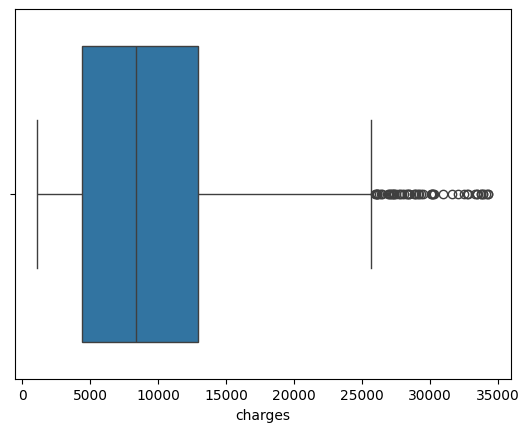

In [ ]:
sns.boxplot(x=df['charges'])

Even though are charges still has outliers, they have been reduced. However, this data is now more skewed to the left.

Let's see if we can clean the data even further by removing more outliers

In [ ]:
# attributed:
# col = 'Pregnancies'

# Q1 = df[col].quantile(0.25)
# Q3 = df[col].quantile(0.75)
# IQR = Q3 - Q1
# lower_boundry = Q1 - 1.5*IQR
# upper_boundry = Q3 + 1.5*IQR

# df = df[(df[col] > lower_boundry) & (df[col] < upper_boundry)]

# author: Nadia


column = 'bmi'

q1 = df[column].quantile(0.25)
q3 = df[column].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5*IQR
upper = q3 + 1.5*IQR

df = df[(df[column] > lower) & (df[column] < upper)]

<Axes: xlabel='bmi'>

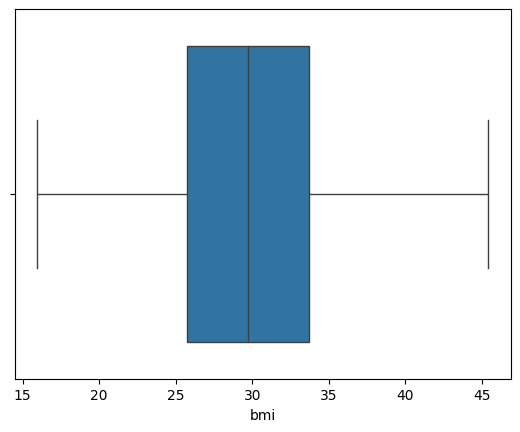

In [ ]:
sns.boxplot(x=df['bmi']) # Let's see if we were successful

Yes! We were able to remove more outliers. The data for bmi is now essentially normally distributed.

In [ ]:
# column = 'charges'

# q1 = df[column].quantile(0.25)
# q3 = df[column].quantile(0.75)
# IQR = q3 - q1
# lower = q1 - 1.5*IQR
# upper = q3 + 1.5*IQR

# df_clean = df[(df[column] > lower) & (df[column] < upper)]

I am not going to remove moreo outliers for charges because when I attempted to do that I generated a blank boxplot.

<Axes: xlabel='charges'>

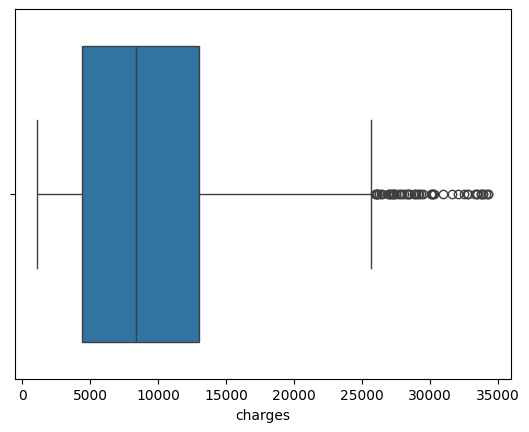

In [ ]:
sns.boxplot(x=df['charges'])

In [ ]:
# how to check for outliers using a "for loop"

# code is from Nadia, from the Decision Trees notebook (April 16th)
# (Nadia, 2026)

for col in df.select_dtypes(include='number').columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_boundry = Q1 - 1.5*IQR
  upper_boundry = Q3 + 1.5*IQR

  outliers = df[(df[col] < lower_boundry) | (df[col] > upper_boundry)]
  if len(outliers):
    print(col, len(outliers))
  else:
    print(col,"NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)")

age NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
sex NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
bmi NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
children NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
smoker 136
region NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
charges 53


In [ ]:
df.shape

(1184, 7)

In [ ]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000
mean,39.006757,0.487331,29.896457,1.080236,0.114865,1.487331,9916.209466
std,14.071726,0.500051,5.749663,1.212564,0.318994,1.111612,7200.593916
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,26.000000,0.000000,25.745000,0.000000,0.000000,1.000000,4411.927350
50%,39.000000,0.000000,29.700000,1.000000,0.000000,1.000000,8378.605575
75%,51.000000,1.000000,33.700000,2.000000,0.000000,2.000000,12979.854925
max,64.000000,1.000000,45.430000,5.000000,1.000000,3.000000,34303.167200


In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_label
0,19,0,27.900,0,1,16884.92400,False,False,True,Smoker
1,18,1,33.770,1,0,1725.55230,False,True,False,Non-smoker
2,28,1,33.000,3,0,4449.46200,False,True,False,Non-smoker
3,33,1,22.705,0,0,21984.47061,True,False,False,Non-smoker
4,32,1,28.880,0,0,3866.85520,True,False,False,Non-smoker
5,31,0,25.740,0,0,3756.62160,False,True,False,Non-smoker
6,46,0,33.440,1,0,8240.58960,False,True,False,Non-smoker
7,37,0,27.740,3,0,7281.50560,True,False,False,Non-smoker
8,37,1,29.830,2,0,6406.41070,False,False,False,Non-smoker
10,25,1,26.220,0,0,2721.32080,False,False,False,Non-smoker


So the bain of my excistence has been the smoker variable, so that is why i checked if I still had smokers and non smokers after the outliers were removed

In [ ]:
df['smoker'].value_counts() #just double checking my smoker variable because I have been having issues with it

,count
smoker,
0,1048
1,136


Now let's have a look at how the data is distributed using the MinMax Scaler.

So what does the MinMaX Scaler do?

It changes values so they fall between 0 and 1 (or -1 and 1 if there are negatives values) (GeeksforGeeks, 2025). It is useful when data is not normally distributed (GeeksforGeeks, 2025). However, it can be affected by outliers, so it works best when there are few or no extreme values.

In [ ]:
# attributed:
# from scipy.stats import zscore

# z_scores = df.select_dtypes(include='number').apply(zscore)

# outliers = (abs(z_scores) > 3)

# print(outliers.sum())

# author: (Nadia, 2026)

from scipy.stats import zscore

z_scores = df.select_dtypes(include='number').apply(zscore)

outliers = (abs(z_scores) > 3)

print(outliers.sum())

age          0
sex          0
bmi          0
children    17
smoker       0
region       0
charges     15
dtype: int64


Okay so I see that children still has outliers, so let me remove those

In [ ]:
Columns = 'children'

q1 = df[Columns].quantile(0.25) #25%
q3 = df[Columns].quantile(0.75) #75%

IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

print(q1, q3)
print(IQR)
print(lower, upper)


outliers = df[(df[Columns] < lower) | (df[Columns] > upper)]
print(Columns, len(outliers))

#CLEAN THE DATA BY REMOVING THE OUTLIERS
df = df[(df[Columns] >= lower) & (df[Columns] <= upper)]

0.0 2.0
2.0
-3.0 5.0
children 0


In [ ]:
# how to check for outliers using a "for loop"

# code is from Nadia, from the Decision Trees notebook (April 16th)
# (Nadia, 2026)

for col in df.select_dtypes(include='number').columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_boundry = Q1 - 1.5*IQR
  upper_boundry = Q3 + 1.5*IQR

  outliers = df[(df[col] < lower_boundry) | (df[col] > upper_boundry)]
  if len(outliers):
    print(col, len(outliers))
  else:
    print(col,"NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)")

age NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
sex NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
bmi NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
children NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
smoker 136
region NO OUTLIERS SO WE HAVE SUCCEEDED! (AT THIS STEP ONLY:)
charges 53


The KDE plot (Kernel Density Estimate) is used to show how values in a continuous variable, like charges or BMI, are distributed. It gives a smooth curve that shows where most data points are concentrated and how spread out the values are (GeekforGeeks, 2025).



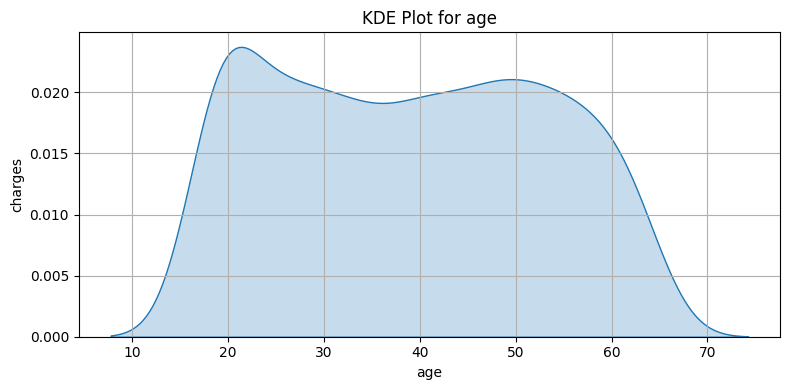

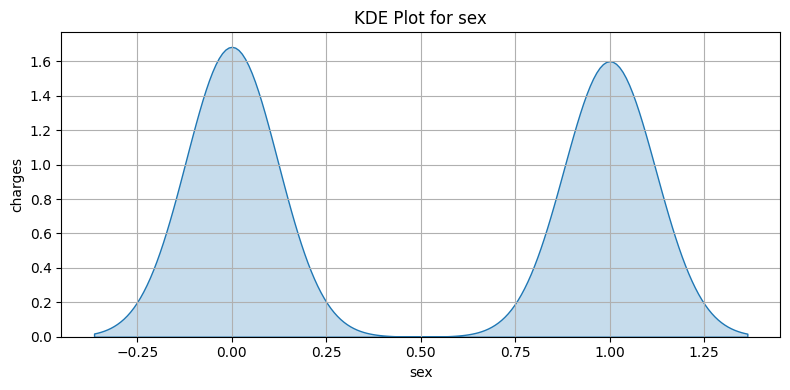

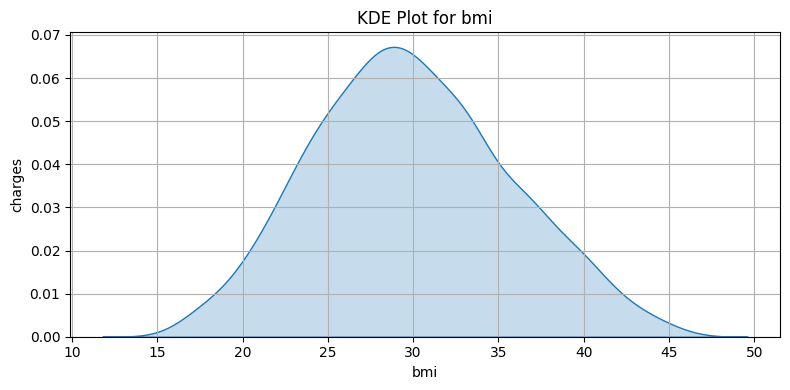

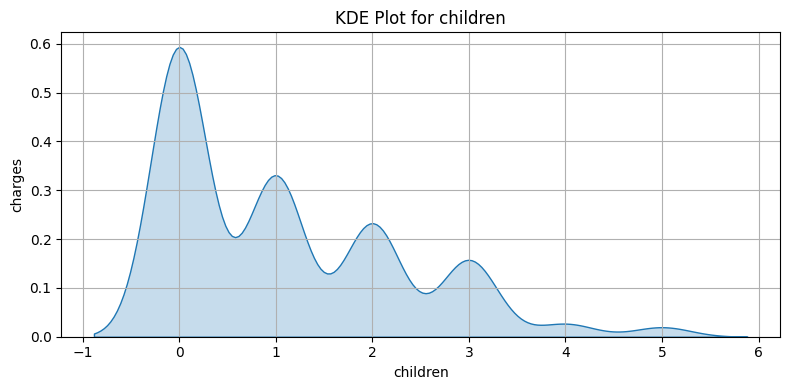

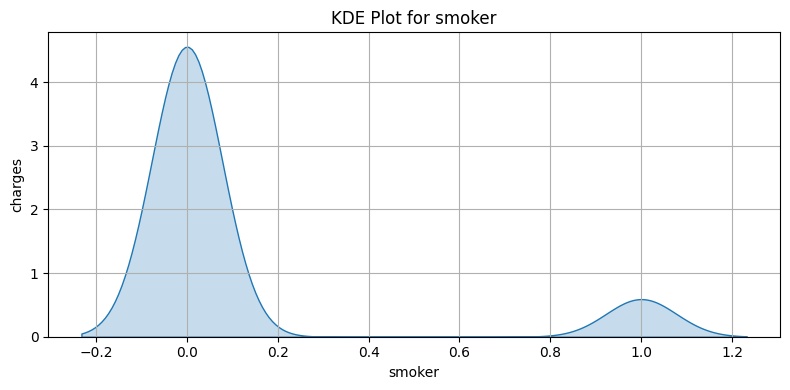

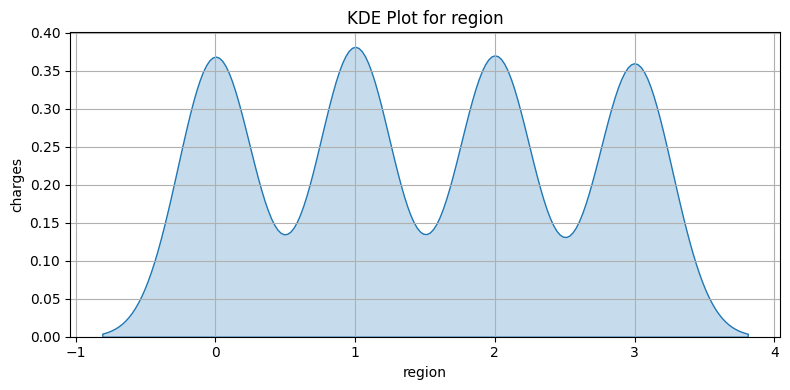

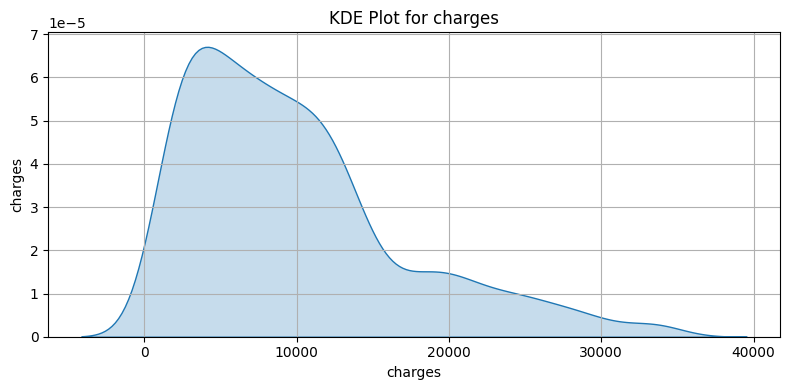

In [ ]:
# attributed = the whole code:)
#author: Sarina

for col in df.select_dtypes(include='number').columns:
  plt.figure(figsize=(8,4))
  sns.kdeplot(data=df, x=col, fill=True)
  plt.title(f'KDE Plot for {col}') # uses string interpolation to put the column name ad the heading
  plt.xlabel(col)
  plt.ylabel('charges')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

sex => normally distributed, because the individual is either male or female

bmi => bmi is not the best representation of normality, however it generally meets the assumption.

children => skewed to the right

smoker => skewed to the right

region => normally distributed

Now that we have visually determined normaility, let's do it statistically using the Shapiro-Wilks Test

Normality can be checked visually using a histrogram or statistically using the Shapiro-Wilk test (P>0.05 normality assumption is met) (Roustaei, 2024).

In [ ]:
# attributed: whole code
#author (Nadia, 2026)

from scipy.stats import shapiro

for col in df.select_dtypes(include='number').columns:
    stat, p = shapiro(df[col].dropna())
    if p > 0.05:
        print(f"{col} looks normally distributed (p={p:.3f})\n")
    else:
        print(f"{col} is NOT normally distributed (p={p:.3f})\n")

age is NOT normally distributed (p=0.000)

sex is NOT normally distributed (p=0.000)

bmi is NOT normally distributed (p=0.000)

children is NOT normally distributed (p=0.000)

smoker is NOT normally distributed (p=0.000)

region is NOT normally distributed (p=0.000)

charges is NOT normally distributed (p=0.000)



So upon statisticasl analysis, none of the data is normally distributed. I am surprised.

### Let's look at the grid heatmaps again to see if anything has changed with correlation following our data cleaning (particularly the removal of outliers)

<Axes: >

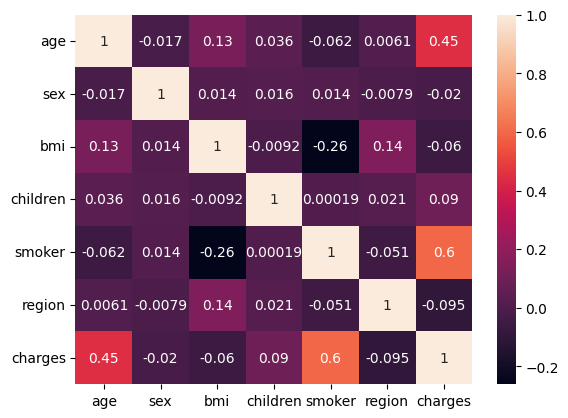

In [ ]:
newcorrelation = df.corr()

sns.heatmap(newcorrelation, annot=True)


smoker => still has the highest correlation with changes, however the correlation has decreased slightly.

region => still has the least affect on charges (lowest correlation)

From this we can see that smoker and age have the greatest affect on charges.

Let's statistically view the new correlations which we got following the removal of outliers

In [ ]:
newcorr = df.corr(numeric_only=True) #newcorr, so it is confused with "corr"
print(newcorr)

               age       sex       bmi  children    smoker    region   charges
age       1.000000 -0.017167  0.126103  0.036331 -0.062129  0.006058  0.447936
sex      -0.017167  1.000000  0.014159  0.016316  0.014430 -0.007893 -0.019900
bmi       0.126103  0.014159  1.000000 -0.009201 -0.260935  0.144207 -0.060134
children  0.036331  0.016316 -0.009201  1.000000  0.000192  0.020509  0.090170
smoker   -0.062129  0.014430 -0.260935  0.000192  1.000000 -0.050721  0.596349
region    0.006058 -0.007893  0.144207  0.020509 -0.050721  1.000000 -0.095387
charges   0.447936 -0.019900 -0.060134  0.090170  0.596349 -0.095387  1.000000


So to check for correlations (or lack thereof) we can use using the Variance Inflation Factro (VIF), whereby a VIF of 1 indicates a lack of correlation, between 1-5 is a mild correlation, between 5-10 a strong correlation while a VIF of above 10 is now a serious problem to the point that predictions would now become reliable (Roustaei, 2024)

In [ ]:
# attributed = whole code
# author (Nadia, 2026)

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# attributed = whole code
# author (Sarina, 2026)

def compute_vif(df):
  X = add_constant(df)

  vif = pd.DataFrame()
  vif['feature'] = X.columns
  vif["VIF"] = [variance_inflation_factor (X.values, i)
                for i in range(X.shape[1])]

  return(vif)

In [ ]:
# attributed = whole code
# author (Sarina, 2026)

# ALSO GEMINI ON GOOGLE COLLAB HELPED ME, I ASKED IT TO EXPLAIN THE ERROR THAT I KEPT ON GETTING, THAN I RAN THE CODE AFTER ACCEPTING ITS RESPONSE

# Handle NaN values before computing VIF
# First, identify columns that are entirely NaN and drop them as they are not useful
# cols_to_drop_if_all_nan = []
# for col in X.columns:
    # if X[col].isnull().all():
      #   cols_to_drop_if_all_nan.append(col)
       #  print(f"Warning: Column '{col}' is entirely NaN and will be dropped for VIF calculation.")

# if cols_to_drop_if_all_nan:
   #  X = X.drop(columns=cols_to_drop_if_all_nan)

# Then drop any remaining rows with NaN values (e.g., if some columns had partial NaNs)
# X = X.dropna()

# Check if X is empty after dropping NaNs and potentially all-NaN columns
# if X.empty:
    # print("DataFrame X is empty after dropping NaN values. Cannot compute VIF.")
# else:
    # vif_df = compute_vif(X)
    # print(vif_df.sort_values(by='VIF', ascending=False))


    feature        VIF
0     const  33.714807
2       bmi   1.038160
4    region   1.021913
1       age   1.017790
3  children   1.002025


#### DISCLAMER!!

#### WHEN I ATTEMEPTED TO DO THE VIF IT REALLY WAS NOT WORKING OUT. THE SMOKER AND SEX VARIABLES BECAME NAN VARIABLES AND YEAH IT HONESTLY JUST DID NOT WORK

#### AND AS YOU CAN SEE I TRIED TO USE GEMINI TO TRY TROUBLESHOOT TO NO AVAIL. I REALLY TRIED:(

So this code is a # because I did run it. however running it sort of creates the mess with the nans.


However, from the inforamtion that I could generate from the vif:
from the predictors I could use, their vif values were very close to 1.

This is good beacause a vif value of 1 means that there is no correlation with other predictors.  

Therefore, based on these scores the assumption of no multicollinearity is met.

In [ ]:
df['sex'] = df['sex'].astype(str).str.lower().map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].astype(str).str.lower().map({'yes': 1, 'no': 0})

According to my attempt, there is is a mild correlation between bmi, region, age, and children with charges, respectively. This is because their vif values are between 1-5 (Roustaei, 2024) HOWEVER, I DO NOT BELIEVE THIS. I THINK IT IS DUE TO MY ERRORS.

So I think I am missing something in regards to sex and smoker, but I know from the Shapiro, the Pearsons correlation and the grid heatmaps that smoker has a correlation with charges.

Okay, all the information from the data cleaning that has been performed at equiped me with the knowledge to now determine which columns need to be dropped.

I am basing the variables that I am dropping on the statistical results I have gotten exclusing vif

In [ ]:
df = df.drop(['region', 'bmi', 'sex'], axis = 1)

In [ ]:
df.head()

,age,children,smoker,charges
0,19,0,1,16884.92400
1,18,1,0,1725.55230
2,28,3,0,4449.46200
3,33,0,0,21984.47061
4,32,0,0,3866.85520


In [ ]:
newcorr2 = df.corr()

In [ ]:
correlation = df.corr(numeric_only=True)['charges']
print(newcorr2)

               age  children    smoker   charges
age       1.000000  0.036331 -0.062129  0.447936
children  0.036331  1.000000  0.000192  0.090170
smoker   -0.062129  0.000192  1.000000  0.596349
charges   0.447936  0.090170  0.596349  1.000000


# Training and Predicting the Linear Regression Model

## Let's build the model

In [ ]:
x = df.drop('charges', axis=1)
y = df['charges']

# x = the questions, y = the answers

In [ ]:
df.head()

,age,children,smoker,charges
0,19,0,1,16884.92400
1,18,1,0,1725.55230
2,28,3,0,4449.46200
3,33,0,0,21984.47061
4,32,0,0,3866.85520


In [ ]:
df.describe().T # Adding the 'T' just changes the orientation of the table

,count,mean,std,min,25%,50%,75%,max
age,1184.0,39.006757,14.071726,18.0000,26.00000,39.000000,51.000000,64.0000
children,1184.0,1.080236,1.212564,0.0000,0.00000,1.000000,2.000000,5.0000
smoker,1184.0,0.114865,0.318994,0.0000,0.00000,0.000000,0.000000,1.0000
charges,1184.0,9916.209466,7200.593916,1121.8739,4411.92735,8378.605575,12979.854925,34303.1672


### How am I going to split the data to train the model?

### Split => Training (80%) Testing (20%)

I'm using the library (train_test_split) from scikitlearn to split that
dataset into training and testing subsets for the linear regression model machine learning.

The 0.2 => testing

So why 42 as the radom_state?
Apparently it's a famous joke from The Hitchhiker’s Guide to the Galaxy, where 42 is “the answer to life, the universe, and everything:)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

x_train:  (947, 3)
x_test:  (237, 3)
y_train:  (947,)
y_test:  (237,)


The machine learning model I am going to use => LinearRegression

In [ ]:
regressor = LinearRegression()

In [ ]:
regressor.fit(x_train, y_train)

LinearRegression()

We need to use the trained model to make predictions based on the test data. Then we'll store the results in 'predictions'

In [ ]:
predictions = regressor.predict(x_test)

In [ ]:
print(predictions)

[10569.4336388   3266.4443748  13595.78063202  5294.06328286
 18182.96665736 10058.75856956 11834.81028523 14091.37433238
  3762.03807516 23961.47139809  3784.66012847 10058.75856956
 25211.76667565  3533.09293607  3281.52574367 12330.40398559
 10828.54151563 12337.94467003 11812.18823192  5767.03492991
  6795.92575282 13077.56487835 14838.53522514 22962.74331294
  8549.35541517 12841.07905482 22444.52755927  7802.19452241
  6803.46643725 10569.4336388   3777.11944403 20927.58372044
  4272.71314439 13839.80713998 11827.26960079 13595.78063202
 11080.10870803  9814.7320616  13847.34782442  2275.25697408
  7024.87089191  4280.25382883  7055.03362965  2275.25697408
  8031.1396615  10051.21788513  5789.65698322 25958.92756841
  9067.57116884  2275.25697408 11072.5680236  10051.21788513
 10317.8664464  12337.94467003 13085.10556279 13092.64624722
  8061.30239925  4036.22732087  2526.82416647  9311.5976768
 26210.49476081  8305.32890721 12581.97117799 12337.94467003
  2778.39135887  2275.256

Now let's measure how accurately the model predicts the test data using the following regression metrics:

MAE => the average size of prediction errors (it's simple and easy to interpret) (GeeksforGeeks, 2026).

MSE => the average of squared errors (it penalizes large mistakes more) (GeeksforGeeks, 2026).

RMSE => the square root of MSE (like MSE but in original units) (GeeksforGeeks, 2026).

R² => tells us how much of the variation in the data is explained by the model  (the closer it is to 1, the moore the variation is explained by the model) (GeeksforGeeks, 2026).

In [ ]:
score = regressor.score(x_test, y_test)

In [ ]:
print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions))
print("R2:", r2_score(y_test, predictions))

MAE: 2903.270924465214
MSE: 27212919.810261656
R2: 0.47027476871259544


47% of the variation is explained by the model

Now let's check for overfitting



In [ ]:
train_score = regressor.score(x_train, y_train)
testing_score = regressor.score(x_train, y_train)

print(train_score)
print(testing_score)

0.6253738431992361
0.6253738431992361


I generated a training and test score which were the same. This means that there was no overfitting (Strebeck, 2018).

However, the score of about 0.63 shows only moderate performance. This suggests the model is consistent but not capturing all patterns in the data, so there is still room for improvement.

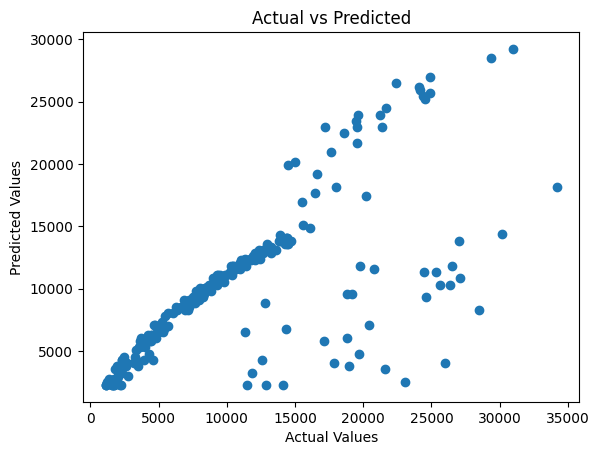

In [ ]:
# attributed:
# import matplotlib.pyplot as plt
# import numpy as np

# xpoints = np.array([0, 6])
# ypoints = np.array([0, 250])

# plt.plot(xpoints, ypoints)
# plt.show()

# author: W3Schools


import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.model_selection import validation_curve

## Hyperparameter Tuning





Our model explains only 47% of the variation found in the data. This is not a lot, so I will try hyperparameter tuning to try and determine if I can get a better result (GeeksforGeeks, 2025)

Let's get the parameter names and values

In [ ]:
regressor.get_params()

# (GeeksforGeeks, 2025)

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

I can now use the above output to build a set of possible values for each parameter. Each parameter can take different values depending on what type of input it accepts (GeeksforGeeks, 2025)

In [ ]:
#attribution: whole code
# author: (GeeksforGeeks)



param_space = {'copy_X': [True,False],
               'fit_intercept': [True,False],
               'n_jobs': [1,5,10,15,None],
               'positive': [True,False]}

Lert's try and find the best combination of hyperparameter values using Scikit-Learn's RandomizedSearchCV (GeeksforGeeks, 2025).

This tool will improve the model I made by testing different hyperparameter settings randomly instead of trying every possible option. It uses cross validation to run many trials and then selects the best combination that gives the highest performance (Shekarreddy, 2024).

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

Here the RandomizedSearchCV is going to test different model settings randomly over 100 trials, using 5 fold cross validation each time to check performance.

Following this, it will choose the combination of settings that gives the best results.

In [ ]:
random_search = RandomizedSearchCV(regressor, param_space, n_iter=100, cv=5)
random_search.fit(x_train, y_train)

# Parameter which gives the best results
print(f"Best Hyperparameters: {random_search.best_params_}")

# Accuracy of the model after using best parameters
print(f"Best Score: {random_search.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters: {'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}
Best Score: 0.6219652413696757


The 0.623 is the represents the best average performance the model achieve.

This means that 62% of the variation in the data is now explained by the model.

Therefore, the hyperparameter tuning worked and the model is now making better predictions than before!